In [1]:
import sys
sys.path.append('/Users/kelly/koskella_lab')
from tools import *
import plotly.express as px
import string

In [2]:
df = pd.read_csv('/Users/kelly/Downloads/RBG_data/KH_RBG3_10092025.csv')
df = clean_and_transpose(df, 31, 129)
df
df1 = df.copy()

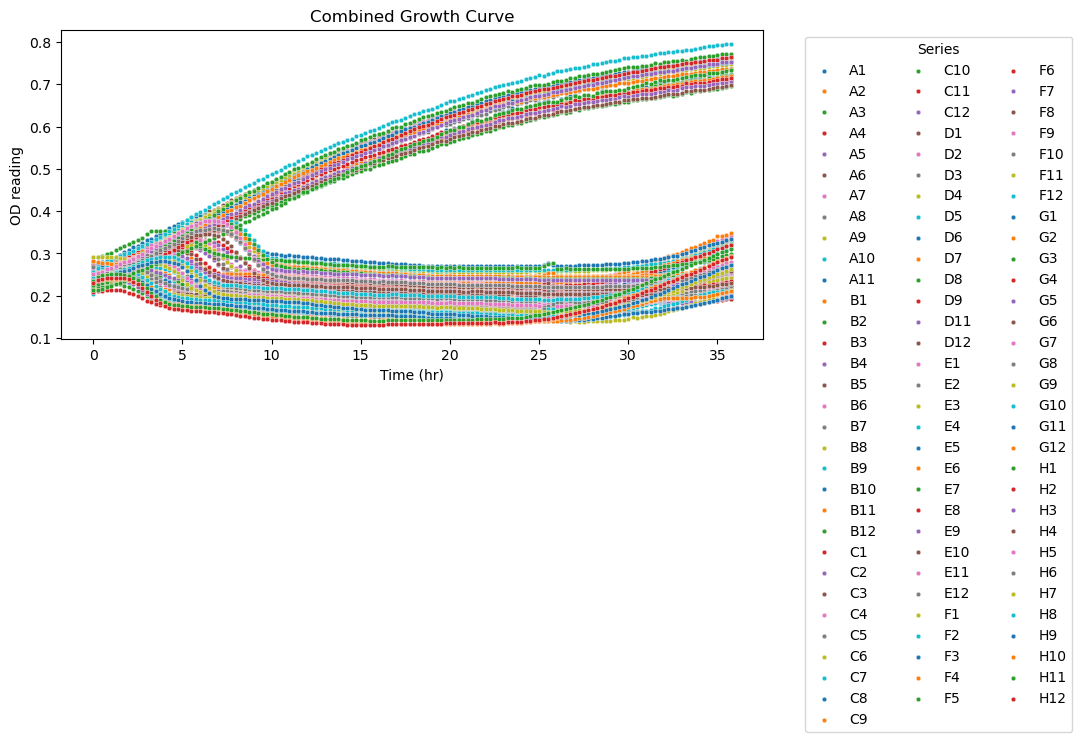

In [3]:
clean_df = remove_outliers(df1, 1, 0.10, 0.3)
plot_timeseries(clean_df, 'Combined Growth Curve')

In [70]:
#each row is a biological replicate, so average every 3 wells

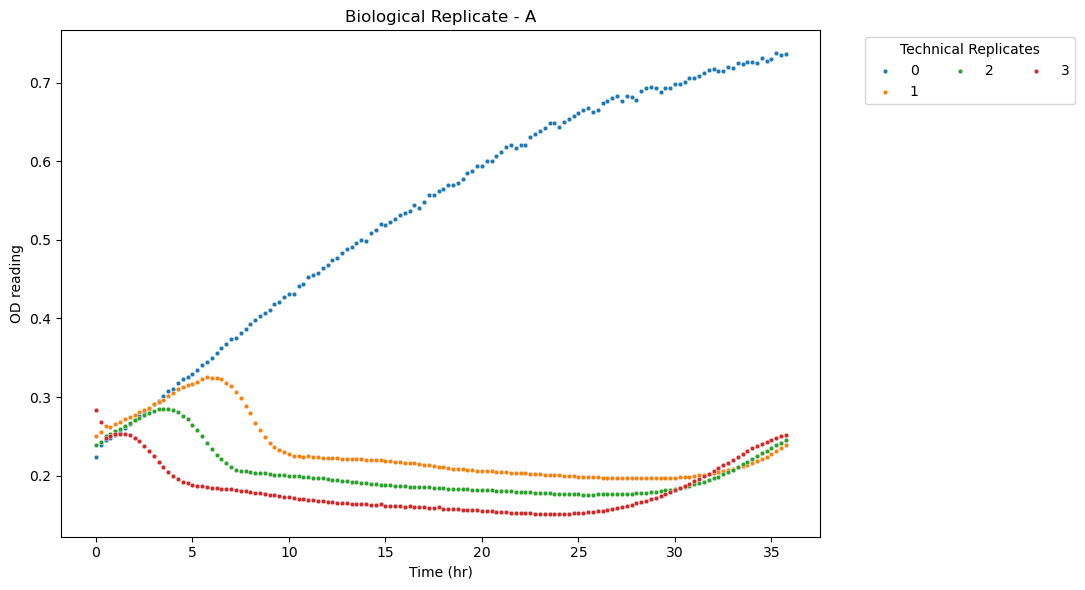

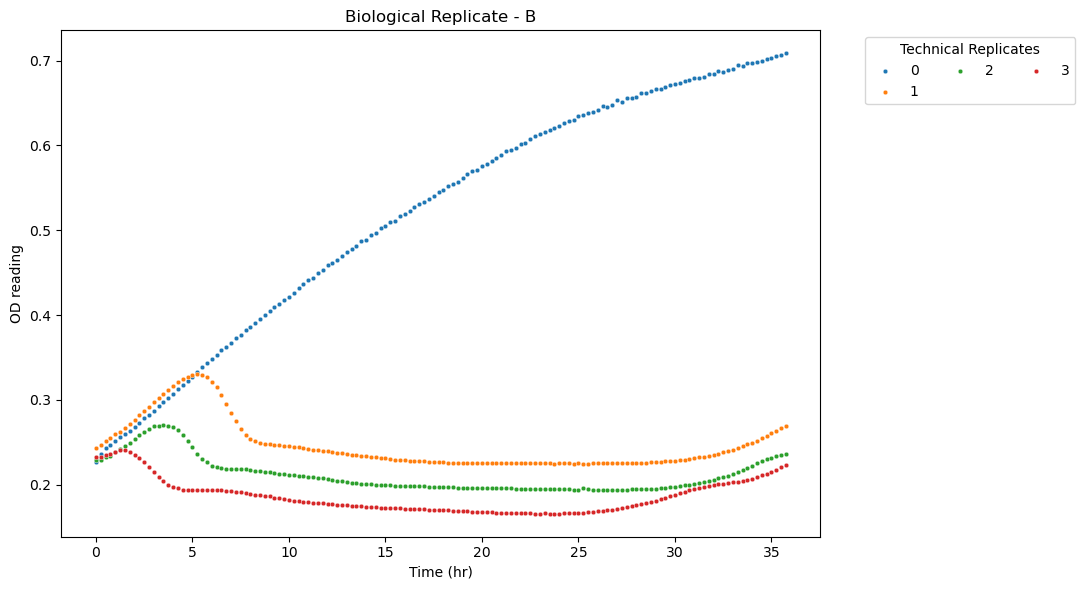

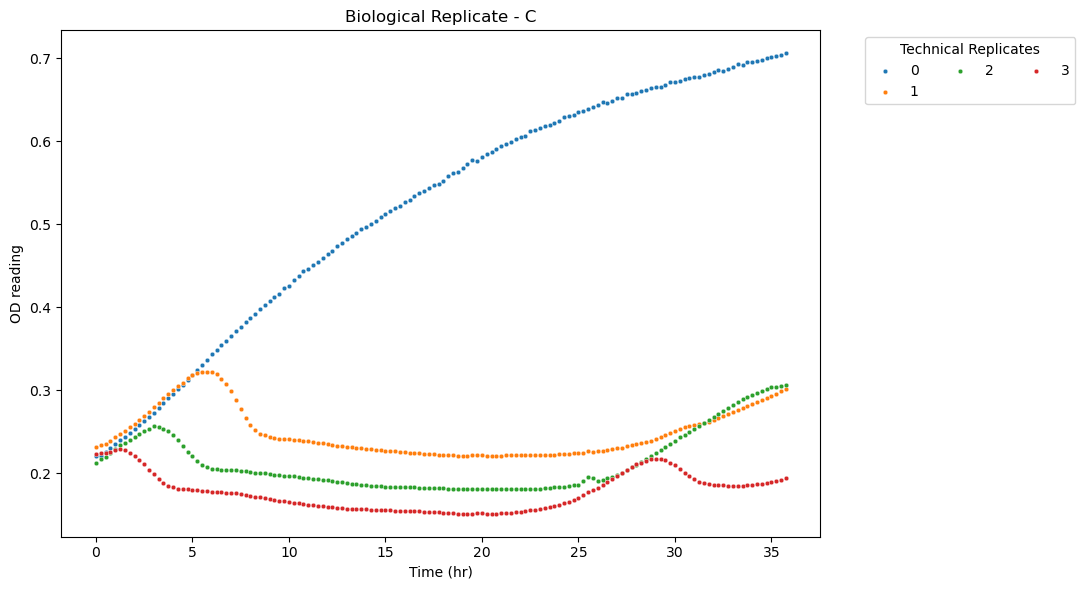

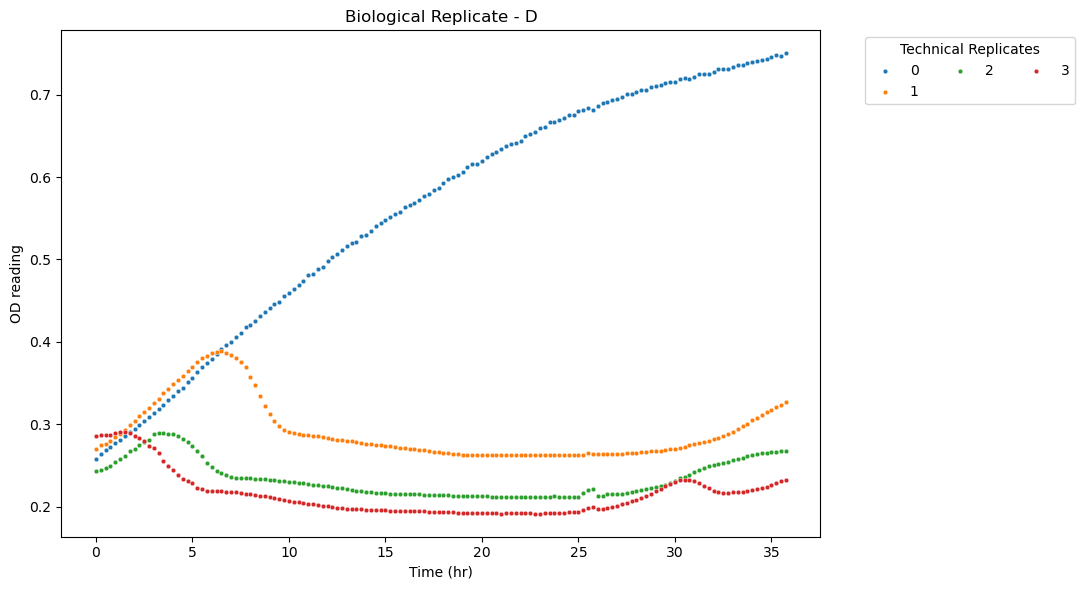

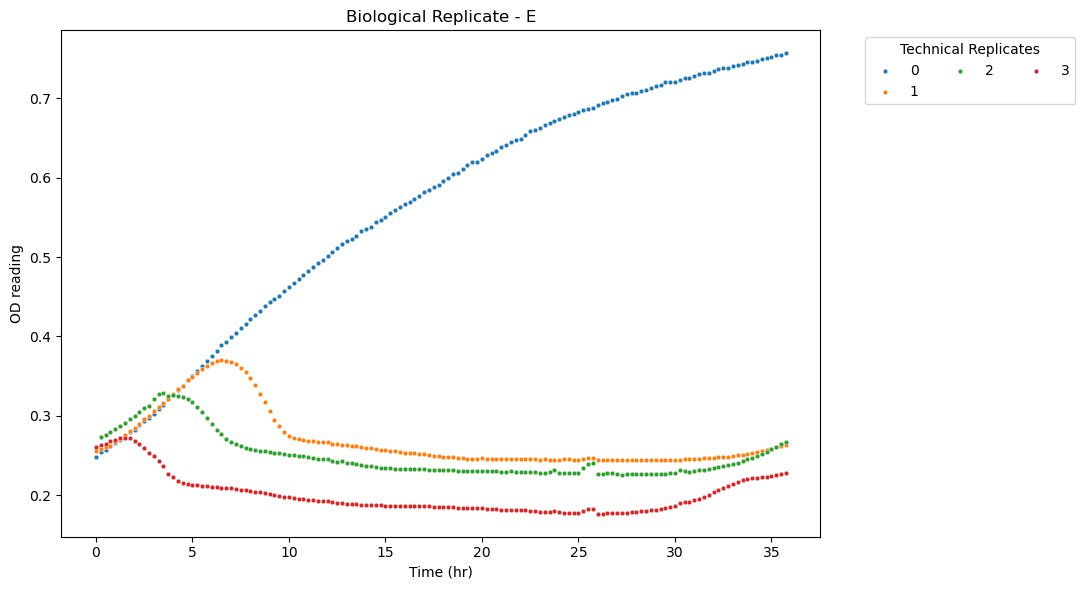

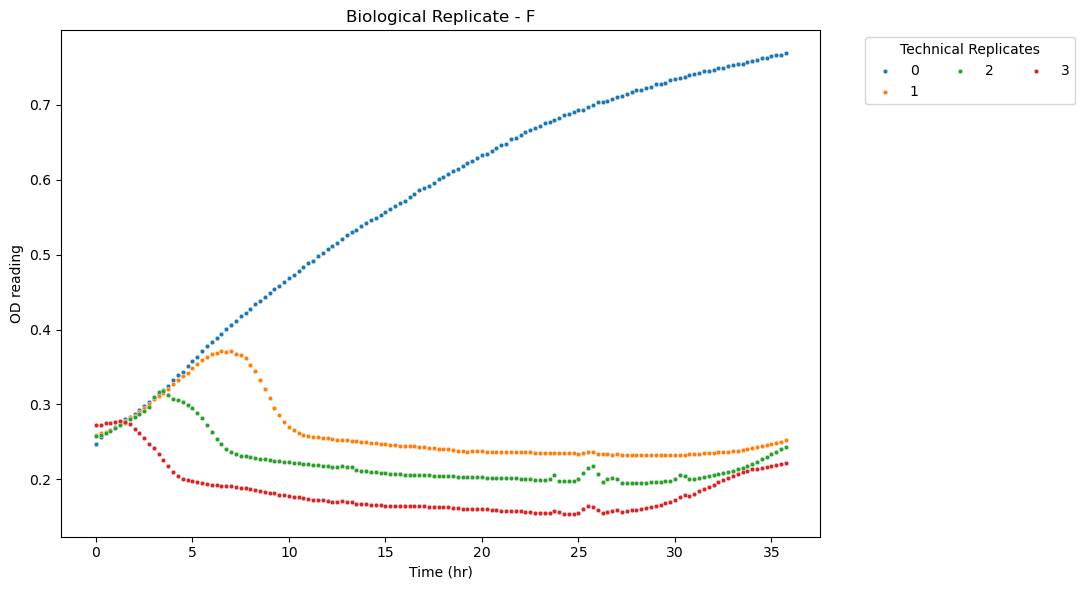

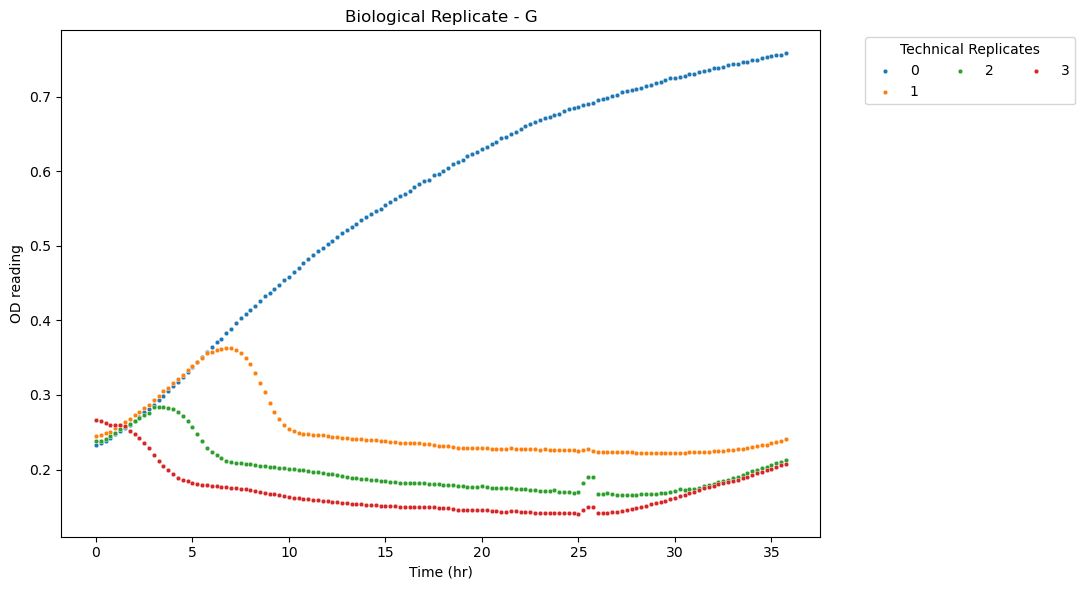

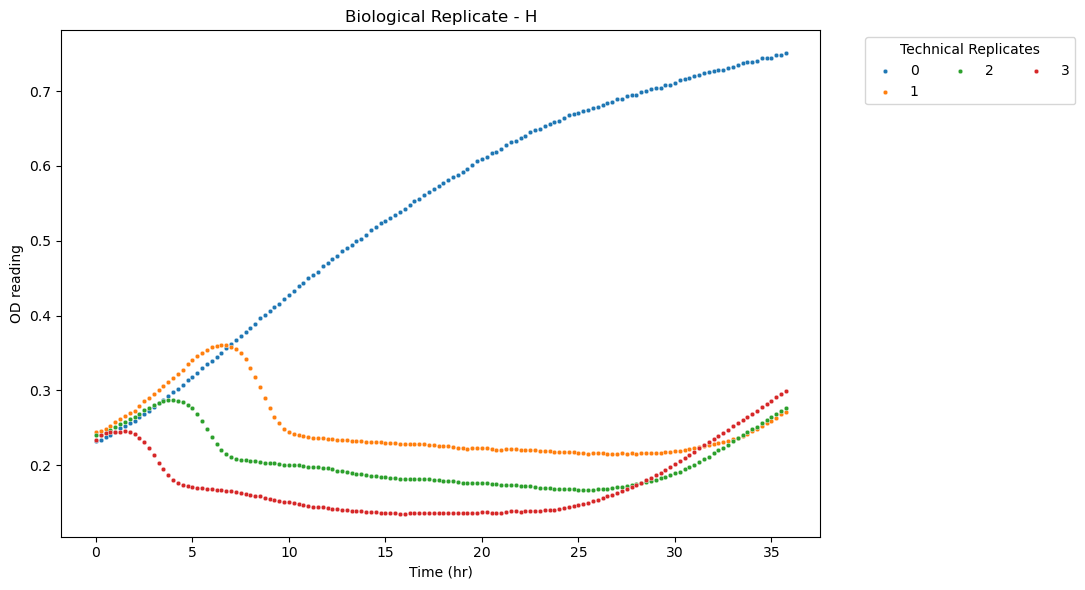

In [10]:
#split into 4 tables of technical replicates

for i, letter in enumerate(list(string.ascii_uppercase[:8]), start=1):
    # filter columns that contain the letter (e.g. "A", "B", etc.)
    table = df.filter(regex=fr'{letter}')
    
    # average every 3 columns
    table_avg = table.groupby(np.arange(table.shape[1]) // 3, axis=1).mean()
    
    # plot — label each with its replicate letter
    plot_timeseries(table_avg, f'Biological Replicate - {letter}', "Technical Replicates")
    

In [6]:
# Round time index to nearest hour
clean_df.index = np.round(clean_df.index).astype(int)

# Select only hours 0–15
df_hourly = clean_df.loc[clean_df.index.isin(range(0, 16))]

# In case there are multiple rows per hour, take the first
df_hourly = df_hourly.groupby(df_hourly.index).first()

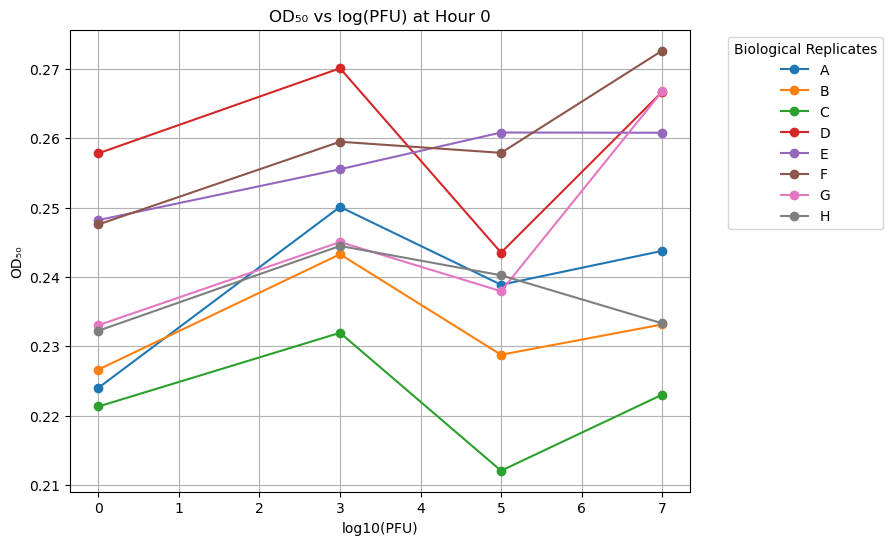

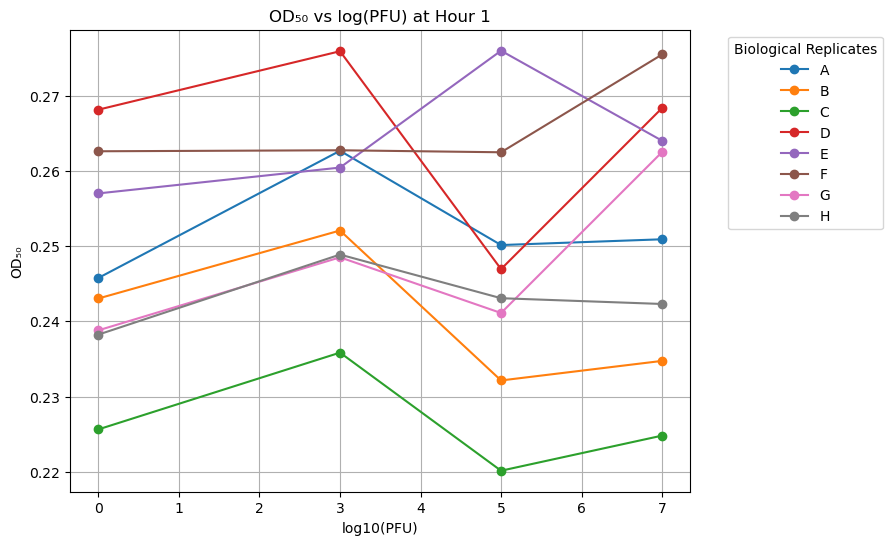

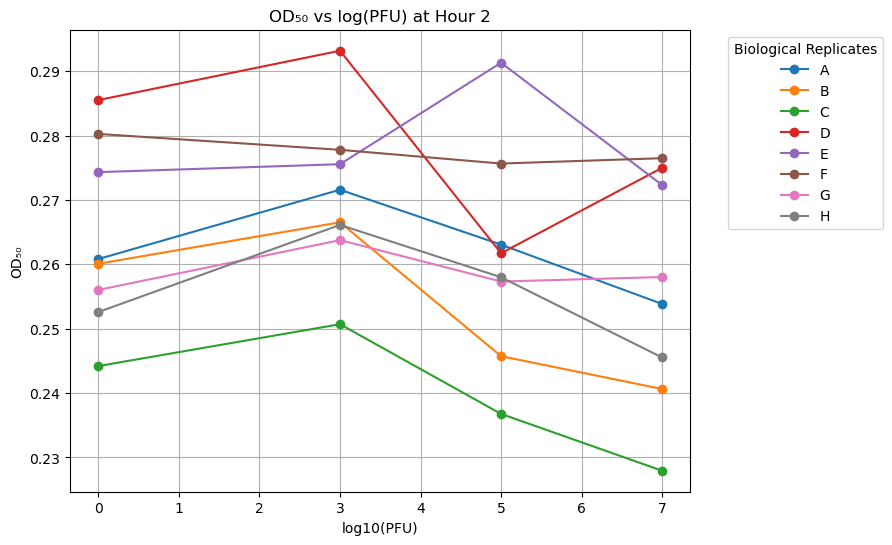

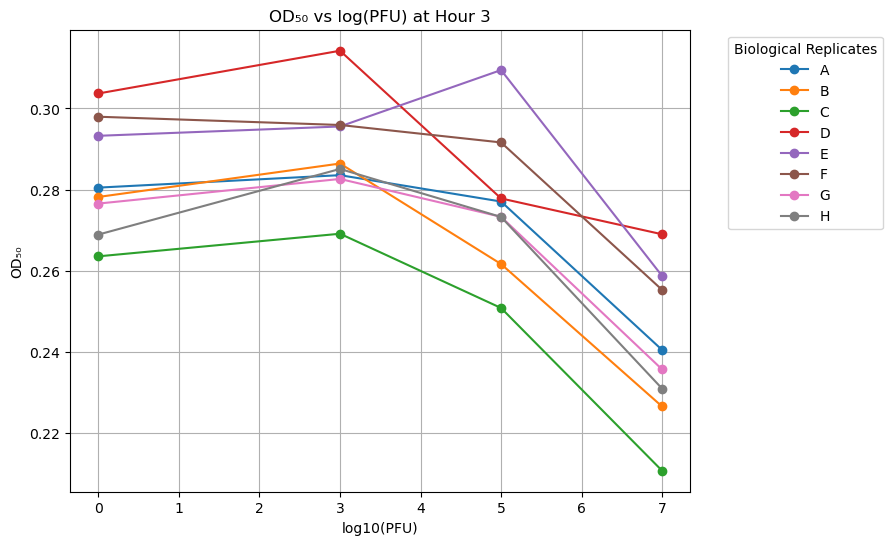

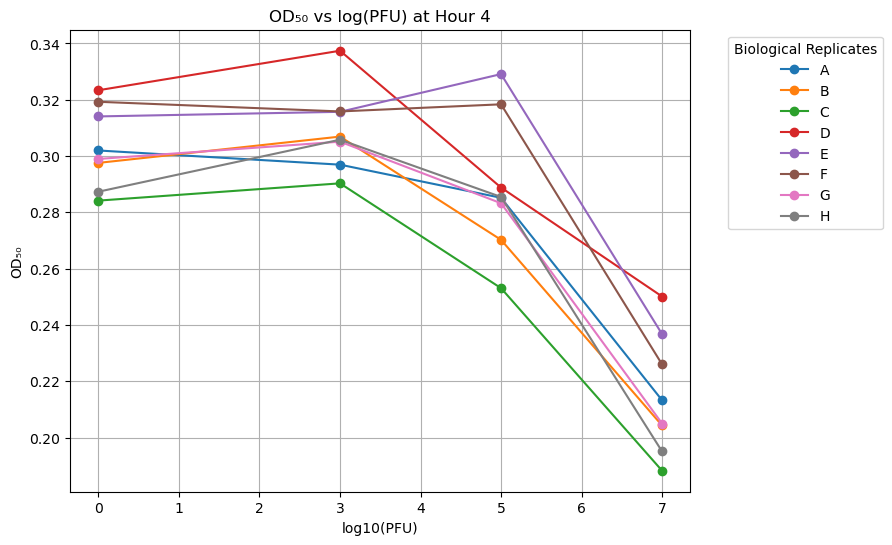

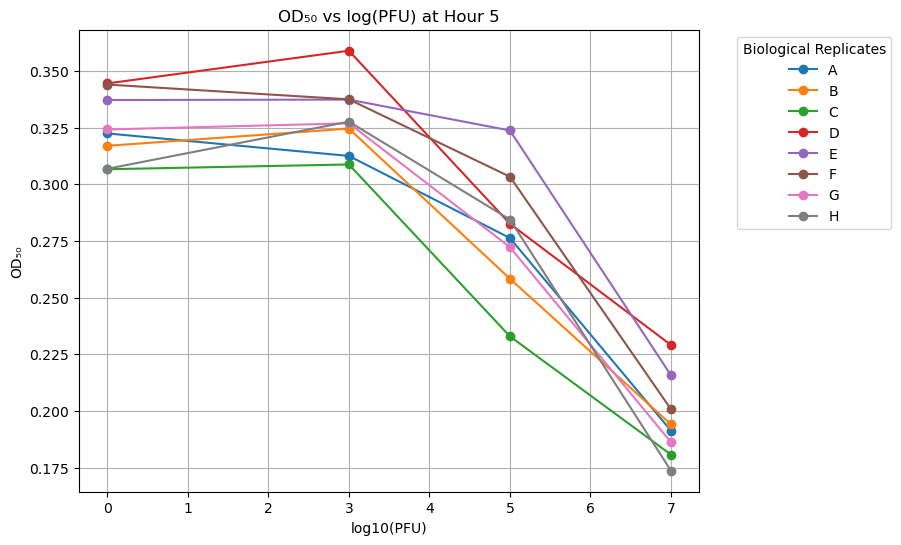

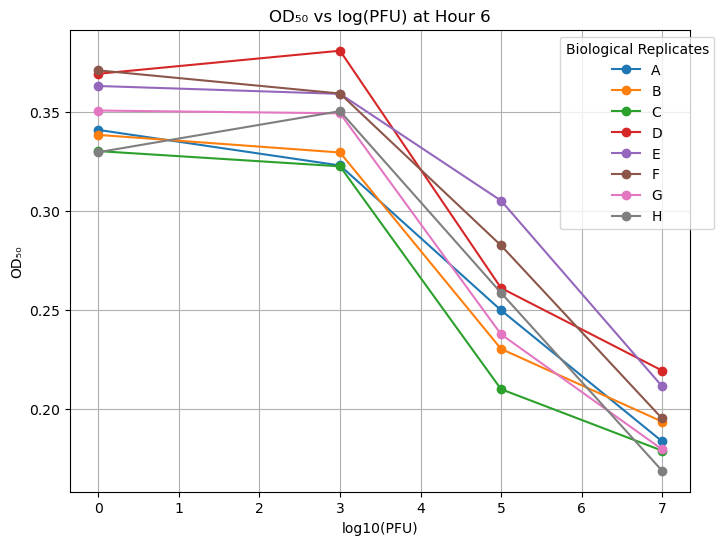

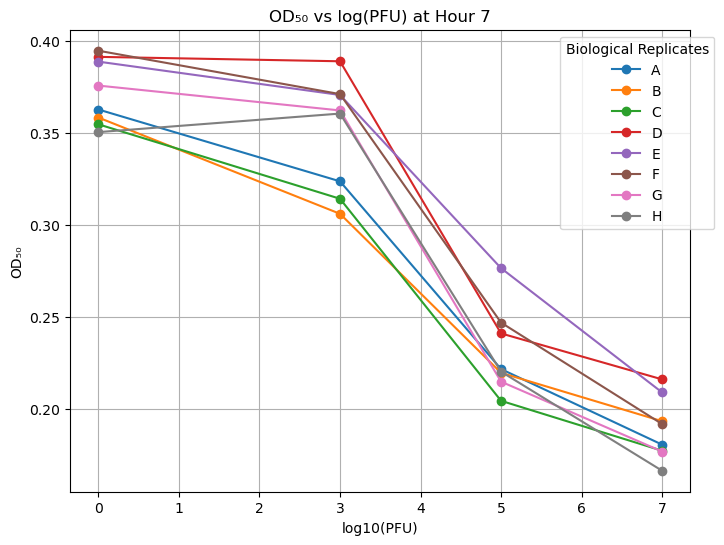

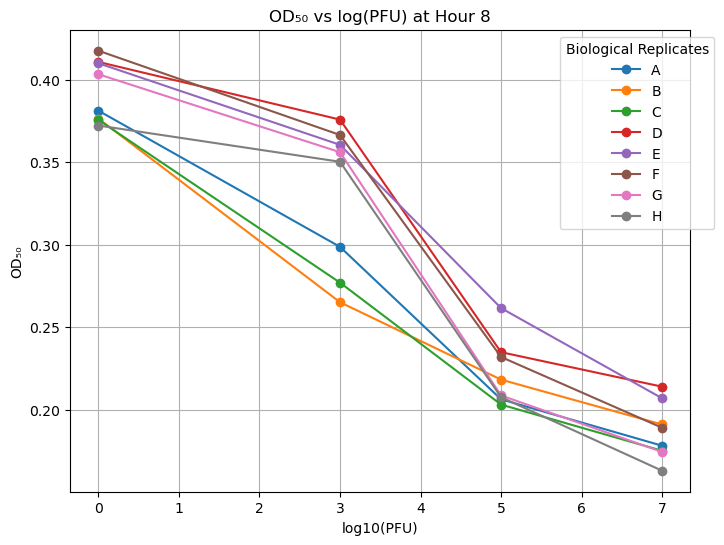

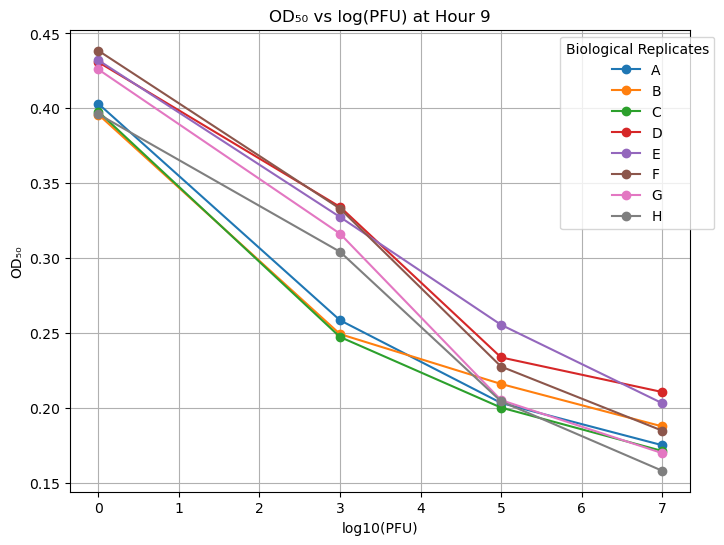

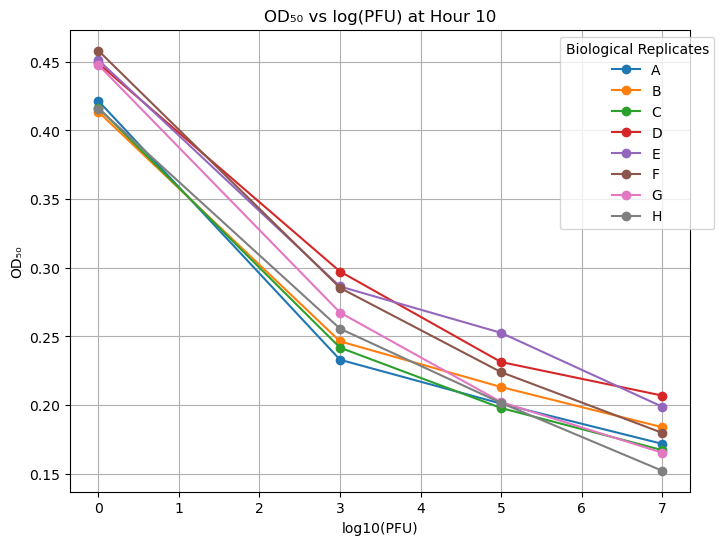

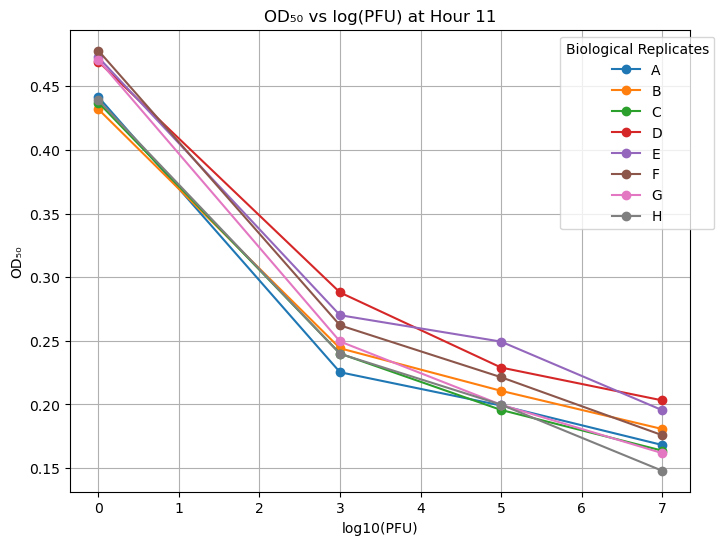

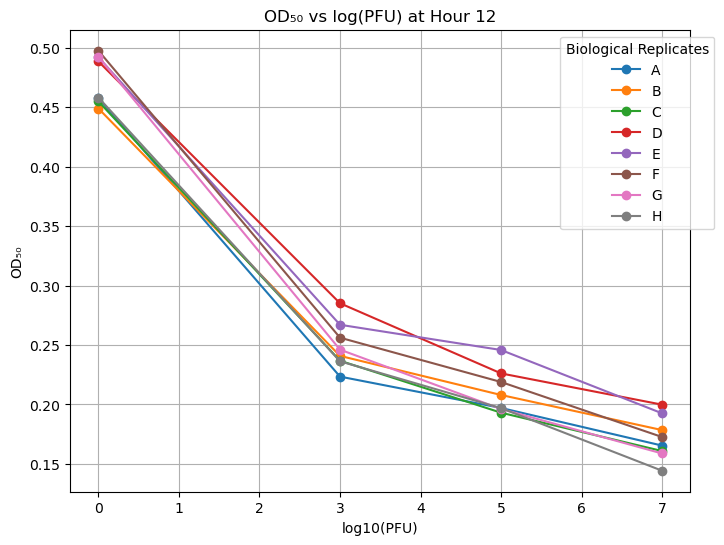

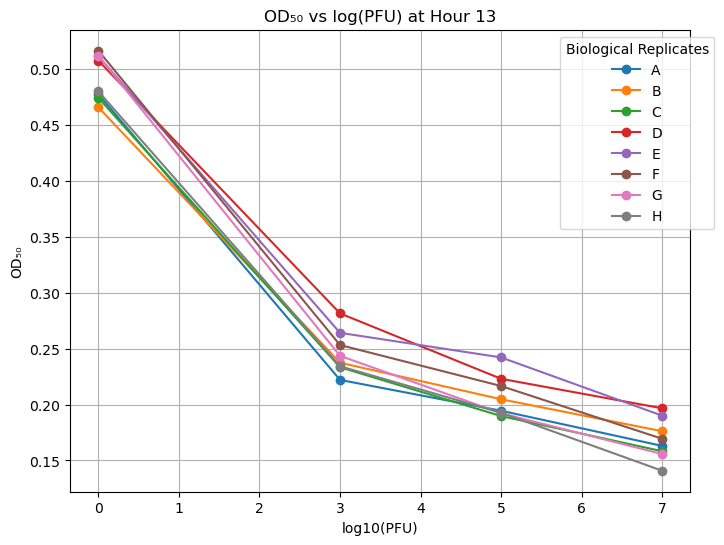

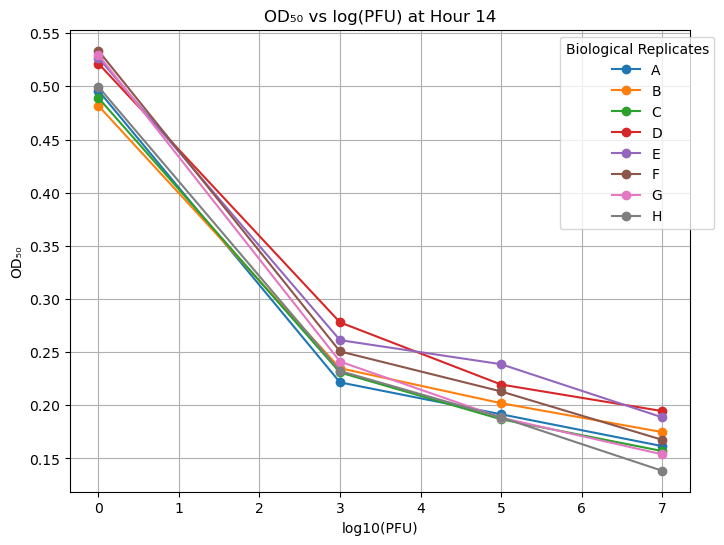

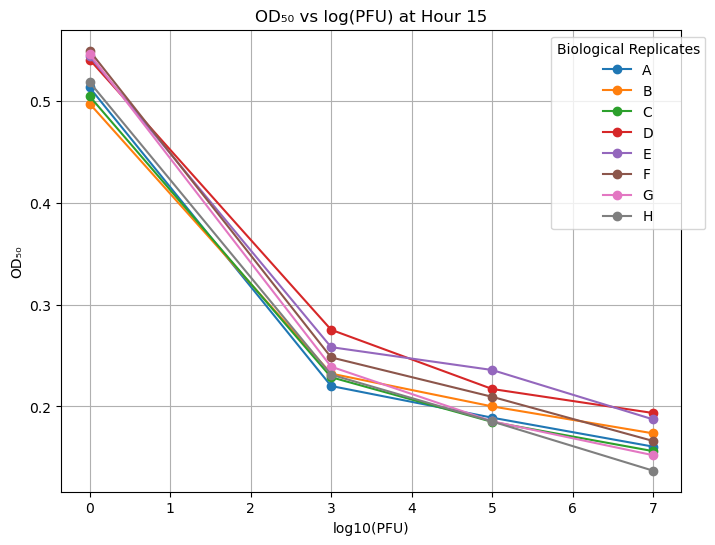

In [13]:
# PFU values and log10 for x-axis
pfu = [0, 1e3, 1e5, 1e7]
x_val = [0 if p==0 else np.log10(p) for p in pfu]

bio_reps = list('ABCDEFGH')

# Loop over hours
for time_idx, row in df_hourly.iterrows():
    if time_idx > 15:  # only 0–15
        break

    avg_dict = {}

    for letter in bio_reps:
        # Select columns for this bio replicate
        table = df_hourly.filter(regex=f'^{letter}')
        # Average every 3 technical replicates
        table_avg = pd.DataFrame({
            i: table.iloc[:, i*3:(i+1)*3].mean(axis=1) for i in range(4)
        })
        # Take the row for this hour
        avg_dict[letter] = table_avg.loc[time_idx].values

    # Plot for this hour
    plt.figure(figsize=(8,6))
    for letter in bio_reps:
        plt.plot(x_val, avg_dict[letter], marker='o', label=letter)

    plt.xlabel('log10(PFU)')
    plt.ylabel('OD₅₀')
    plt.title(f'OD₅₀ vs log(PFU) at Hour {time_idx}')
    plt.legend(title='Biological Replicates', bbox_to_anchor=(1.05, 1))
    plt.grid(True)
    plt.show()

In [11]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# PFU values and log10 for x-axis
pfu = [0, 1e3, 1e5, 1e7]
x_val = [0 if p==0 else np.log10(p) for p in pfu]

bio_reps = list('ABCDEFGH')

# Prepare traces for all hours
fig = go.Figure()

for time_idx, row in df_hourly.iterrows():
    if time_idx > 15:
        break

    avg_dict = {}

    for letter in bio_reps:
        table = df_hourly.filter(regex=f'^{letter}')
        table_avg = pd.DataFrame({
            i: table.iloc[:, i*3:(i+1)*3].mean(axis=1) for i in range(4)
        })
        avg_dict[letter] = table_avg.loc[time_idx].values

    # Add a trace for each bio replicate at this hour
    for letter in bio_reps:
        fig.add_trace(
            go.Scatter(
                x=x_val,
                y=avg_dict[letter],
                mode='lines+markers',
                name=f'{letter} (Hour {time_idx})',
                visible=(time_idx==0)  # only hour 0 visible initially
            )
        )

# Create dropdown buttons for each hour
buttons = []
for time_idx in range(16):
    visible = []
    for h in range(16):
        for _ in bio_reps:
            visible.append(h == time_idx)
    buttons.append(dict(
        label=f'Hour {time_idx}',
        method='update',
        args=[{'visible': visible},
              {'title': f'OD vs log(PFU) at Hour {time_idx}'}]
    ))

fig.update_layout(
    updatemenus=[dict(active=0, buttons=buttons, x=1.1, y=1)],
    xaxis_title='log10(PFU)',
    yaxis_title='OD',
    title='OD vs log(PFU) at Hour 0'
)

fig.show()
